In [1]:
#Import the library
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
warnings.filterwarnings('ignore')
 
from scipy.sparse import hstack, csr_matrix
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.feature_extraction.text import HashingVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_curve, auc
)
from sklearn.utils import resample
from sklearn.calibration import CalibratedClassifierCV

In [2]:
#Text Preprocessing
def clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+',  ' url ',       text)
    text = re.sub(r'/u/\w+',           ' user ',      text)
    text = re.sub(r'/r/\w+',           ' subreddit ', text)
    text = re.sub(r'&amp;|&lt;|&gt;', ' ',            text)
    text = re.sub(r'\*+|#+',          ' ',            text)
    text = re.sub(r'\s+',             ' ',            text)
    return text.strip().lower()
 
def make_sarc_text(parent, comment):
    return clean(str(parent)) + ' [reply] ' + clean(str(comment))

In [3]:
#Read and label the Sentiment Data
t0 = time.time()
 
sent_df = pd.read_csv('Reddit_Data.csv')
sent_df = sent_df.dropna(subset=['clean_comment']).reset_index(drop=True)
sent_df['text'] = sent_df['clean_comment'].apply(clean)
 
LABEL_MAP = {1: 'Positive', 0: 'Neutral', -1: 'Negative'}
sent_df['label'] = sent_df['category'].map(LABEL_MAP)

In [4]:
#Rebalance the data, since the dataset is imbalance
pos = sent_df[sent_df['label'] == 'Positive']
neu = sent_df[sent_df['label'] == 'Neutral']
neg = sent_df[sent_df['label'] == 'Negative']
target = len(pos)
sent_balanced = pd.concat([
    pos,
    resample(neu, replace=True, n_samples=target, random_state=42),
    resample(neg, replace=True, n_samples=target, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)
 

In [5]:
#Set the train data and test data
X_sent_train, X_sent_test, y_sent_train, y_sent_test = train_test_split(
    sent_balanced['text'], sent_balanced['label'],
    test_size=0.2, random_state=42, stratify=sent_balanced['label']
)

 
print(f"  Sentiment rows  : {len(sent_df):,}  →  balanced: {len(sent_balanced):,}")
print(f"  Train / Test    : {len(X_sent_train):,} / {len(X_sent_test):,}")
print(f"  Labels          : Positive={target:,}  Neutral={target:,}  Negative={target:,}")

  Sentiment rows  : 37,149  →  balanced: 47,490
  Train / Test    : 37,992 / 9,498
  Labels          : Positive=15,830  Neutral=15,830  Negative=15,830


In [6]:
#Train the Sarcasm first
print("\n" + "=" * 65)
print("  STAGE 1: Training Sarcasm Detector")
print("  Method : HashingVectorizer + MultinomialNB (partial_fit)")
print("  Data   : all 1M rows in 50k chunks")
print("=" * 65)
 
t1 = time.time()

hv = HashingVectorizer(
    ngram_range=(1, 2),
    n_features=2**18,          # 262,144 hash buckets
    alternate_sign=False,      # required for MultinomialNB (non-negative)
    norm='l2',
    strip_accents='unicode',
    token_pattern=r'\b[a-z][a-z]+\b',
)

sarc_clf = MultinomialNB(alpha=0.1)


  STAGE 1: Training Sarcasm Detector
  Method : HashingVectorizer + MultinomialNB (partial_fit)
  Data   : all 1M rows in 50k chunks


In [7]:
#Since dataset contains 1mil data , divided into smaller group for less memory usage
CHUNK_SIZE  = 50000
TEST_CHUNKS = {19}             # hold out chunk index 19 (~last 50k rows)
test_texts, test_labels = [], []
chunks_done = 0
 
for chunk in pd.read_csv(
    'train-balanced-sarcasm.csv',
    chunksize=CHUNK_SIZE
):
    chunk = chunk.dropna(subset=['comment'])
    chunk['text'] = chunk.apply(
        lambda r: make_sarc_text(r['parent_comment'], r['comment']), axis=1
    )
 
    if chunks_done in TEST_CHUNKS:
        test_texts.extend(chunk['text'].tolist())
        test_labels.extend(chunk['label'].tolist())
        chunks_done += 1
        continue
 
    X_chunk = hv.transform(chunk['text'])
    sarc_clf.partial_fit(X_chunk, chunk['label'], classes=[0, 1])
    chunks_done += 1
 
    if chunks_done % 5 == 0:
        elapsed = time.time() - t1
        print(f"  Chunk {chunks_done:>2} / ~21  |  {elapsed:.0f}s elapsed")
 

  Chunk  5 / ~21  |  57s elapsed
  Chunk 10 / ~21  |  110s elapsed
  Chunk 15 / ~21  |  207s elapsed


In [8]:
#Get value respectively
X_sarc_test  = hv.transform(test_texts)
sarc_preds   = sarc_clf.predict(X_sarc_test)
sarc_proba   = sarc_clf.predict_proba(X_sarc_test)[:, 1]
y_sarc_test  = np.array(test_labels)

In [9]:
#Show Sarcasm report
sarc_acc = accuracy_score(y_sarc_test, sarc_preds)
sarc_f1  = f1_score(y_sarc_test, sarc_preds)
 
print(f"\n  Training time   : {time.time()-t1:.0f}s")
print(f"  Accuracy        : {sarc_acc:.4f}  ({sarc_acc*100:.2f}%)")
print(f"  F1 Score        : {sarc_f1:.4f}")
print()
print(classification_report(
    y_sarc_test, sarc_preds,
    target_names=['Not Sarcastic', 'Sarcastic']
))


  Training time   : 571s
  Accuracy        : 0.6754  (67.54%)
  F1 Score        : 0.6948

               precision    recall  f1-score   support

Not Sarcastic       0.64      0.67      0.65     22921
    Sarcastic       0.71      0.68      0.69     27073

     accuracy                           0.68     49994
    macro avg       0.67      0.67      0.67     49994
 weighted avg       0.68      0.68      0.68     49994



In [10]:
#Start training Sentiment Model (Without Sarcasm)
print("=" * 65)
print("  STAGE 2: Training Sentiment Model  (with sarcasm stacking)")
print("=" * 65)
 
t2 = time.time()

  STAGE 2: Training Sentiment Model  (with sarcasm stacking)


In [11]:
#Set the training data
sent_tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=80000,
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode',
    token_pattern=r'\b[a-z][a-z]+\b',
)
X_tfidf_train = sent_tfidf.fit_transform(X_sent_train)
X_tfidf_test  = sent_tfidf.transform(X_sent_test)

In [12]:
# Get sarcasm probability for sentiment texts  ← STACKING
print("  Computing sarcasm probabilities for sentiment texts...")
sarc_prob_train = sarc_clf.predict_proba(hv.transform(X_sent_train))[:, 1]
sarc_prob_test  = sarc_clf.predict_proba(hv.transform(X_sent_test))[:, 1]
 
# Stack: TF-IDF features + sarcasm probability column
X_stack_train = hstack([X_tfidf_train, csr_matrix(sarc_prob_train).T])
X_stack_test  = hstack([X_tfidf_test,  csr_matrix(sarc_prob_test).T])

  Computing sarcasm probabilities for sentiment texts...


In [13]:
#Naive Bayes Model train (Sentiment)
sent_clf = ComplementNB(alpha=0.3)

In [14]:
#Report for Sentiment Analysis (Has Sarcasm features)
sent_clf.fit(X_stack_train, y_sent_train)
sent_preds = sent_clf.predict(X_stack_test)
 
sent_acc = accuracy_score(y_sent_test, sent_preds)
sent_f1  = f1_score(y_sent_test, sent_preds, average='weighted')
 
print(f"\n  Training time   : {time.time()-t2:.1f}s")
print(f"  Accuracy        : {sent_acc:.4f}  ({sent_acc*100:.2f}%)")
print(f"  F1 Score        : {sent_f1:.4f}  (weighted)")
print()
print(classification_report(y_sent_test, sent_preds))
 


  Training time   : 76.2s
  Accuracy        : 0.7928  (79.28%)
  F1 Score        : 0.7944  (weighted)

              precision    recall  f1-score   support

    Negative       0.91      0.70      0.79      3166
     Neutral       0.87      0.77      0.82      3166
    Positive       0.67      0.91      0.77      3166

    accuracy                           0.79      9498
   macro avg       0.82      0.79      0.79      9498
weighted avg       0.82      0.79      0.79      9498



In [15]:
#Sentiment Analysis Report Without Sarcasm
print("=" * 65)
print("  ABLATION: Sentiment WITHOUT sarcasm stacking (baseline)")
print("=" * 65)
 
base_clf   = ComplementNB(alpha=0.3)
base_clf.fit(X_tfidf_train, y_sent_train)
base_preds = base_clf.predict(X_tfidf_test)
base_acc   = accuracy_score(y_sent_test, base_preds)
base_f1    = f1_score(y_sent_test, base_preds, average='weighted')
 
print(f"  Baseline Accuracy : {base_acc:.4f}  ({base_acc*100:.2f}%)")
print(f"  Baseline F1       : {base_f1:.4f}")
print(f"\n  Accuracy gain from stacking : +{(sent_acc-base_acc)*100:.2f}%")
print(f"  F1 gain from stacking       : +{(sent_f1-base_f1):.4f}")

  ABLATION: Sentiment WITHOUT sarcasm stacking (baseline)
  Baseline Accuracy : 0.7683  (76.83%)
  Baseline F1       : 0.7683

  Accuracy gain from stacking : +2.45%
  F1 gain from stacking       : +0.0261


In [16]:
#Flipper, for demo usage
FLIP_MAP = {'Positive': 'Negative', 'Negative': 'Positive', 'Neutral': 'Neutral'}
 
def predict_full(texts, parent_comments=None, sarcasm_threshold=0.5):
    if parent_comments is None:
        parent_comments = [''] * len(texts)
 
    sarc_inputs  = [make_sarc_text(p, t) for p, t in zip(parent_comments, texts)]
    sarc_probs   = sarc_clf.predict_proba(hv.transform(sarc_inputs))[:, 1]
    is_sarcastic = sarc_probs >= sarcasm_threshold
 
    sent_inputs  = [clean(t) for t in texts]
    tfidf_feats  = sent_tfidf.transform(sent_inputs)
    stacked      = hstack([tfidf_feats, csr_matrix(sarc_probs).T])
    sent_labels  = sent_clf.predict(stacked)
    sent_probs   = sent_clf.predict_proba(stacked)
 
    rows = []
    for i, text in enumerate(texts):
        raw   = sent_labels[i]
        final = FLIP_MAP[raw] if is_sarcastic[i] else raw
        rows.append({
            'comment':         text[:70] + ('...' if len(text) > 70 else ''),
            'raw_sentiment':   raw,
            'sarcasm_prob':    round(float(sarc_probs[i]), 3),
            'is_sarcastic':    bool(is_sarcastic[i]),
            'final_sentiment': final,
            'confidence':      round(float(max(sent_probs[i])), 3),
        })
    return pd.DataFrame(rows)

In [18]:
#Demo
print("\n" + "=" * 65)
print("  LIVE INFERENCE DEMO")
print("=" * 65)
 
demo_texts   = [
    "This is genuinely one of the best things I have ever seen",
    "Oh wow great job breaking everything again as usual",
    "Yeah because that totally worked out so well last time right",
    "I really appreciate how thoughtful and detailed this is",
    "Sure because ignoring the problem always fixes it apparently",
    "This is pretty mediocre honestly nothing special here",
]
demo_parents = [
    "Just released the new update today",
    "We pushed a patch to fix the bug yesterday",
    "They tried the same strategy back in 2019",
    "Here is my full analysis of the situation",
    "We decided not to address this issue at this time",
    "What do you think of the new feature they added",
]


  LIVE INFERENCE DEMO


In [19]:
#Demo results
results = predict_full(demo_texts, demo_parents)
pd.set_option('display.max_colwidth', 50)
print(results[['comment','raw_sentiment','sarcasm_prob',
               'is_sarcastic','final_sentiment']].to_string(index=False))

                                                     comment raw_sentiment  sarcasm_prob  is_sarcastic final_sentiment
   This is genuinely one of the best things I have ever seen      Positive         0.422         False        Positive
         Oh wow great job breaking everything again as usual      Positive         0.682          True        Negative
Yeah because that totally worked out so well last time right      Positive         0.873          True        Negative
     I really appreciate how thoughtful and detailed this is      Positive         0.498         False        Positive
Sure because ignoring the problem always fixes it apparently      Positive         0.679          True        Negative
       This is pretty mediocre honestly nothing special here      Positive         0.392         False        Positive



Generating visualisations...


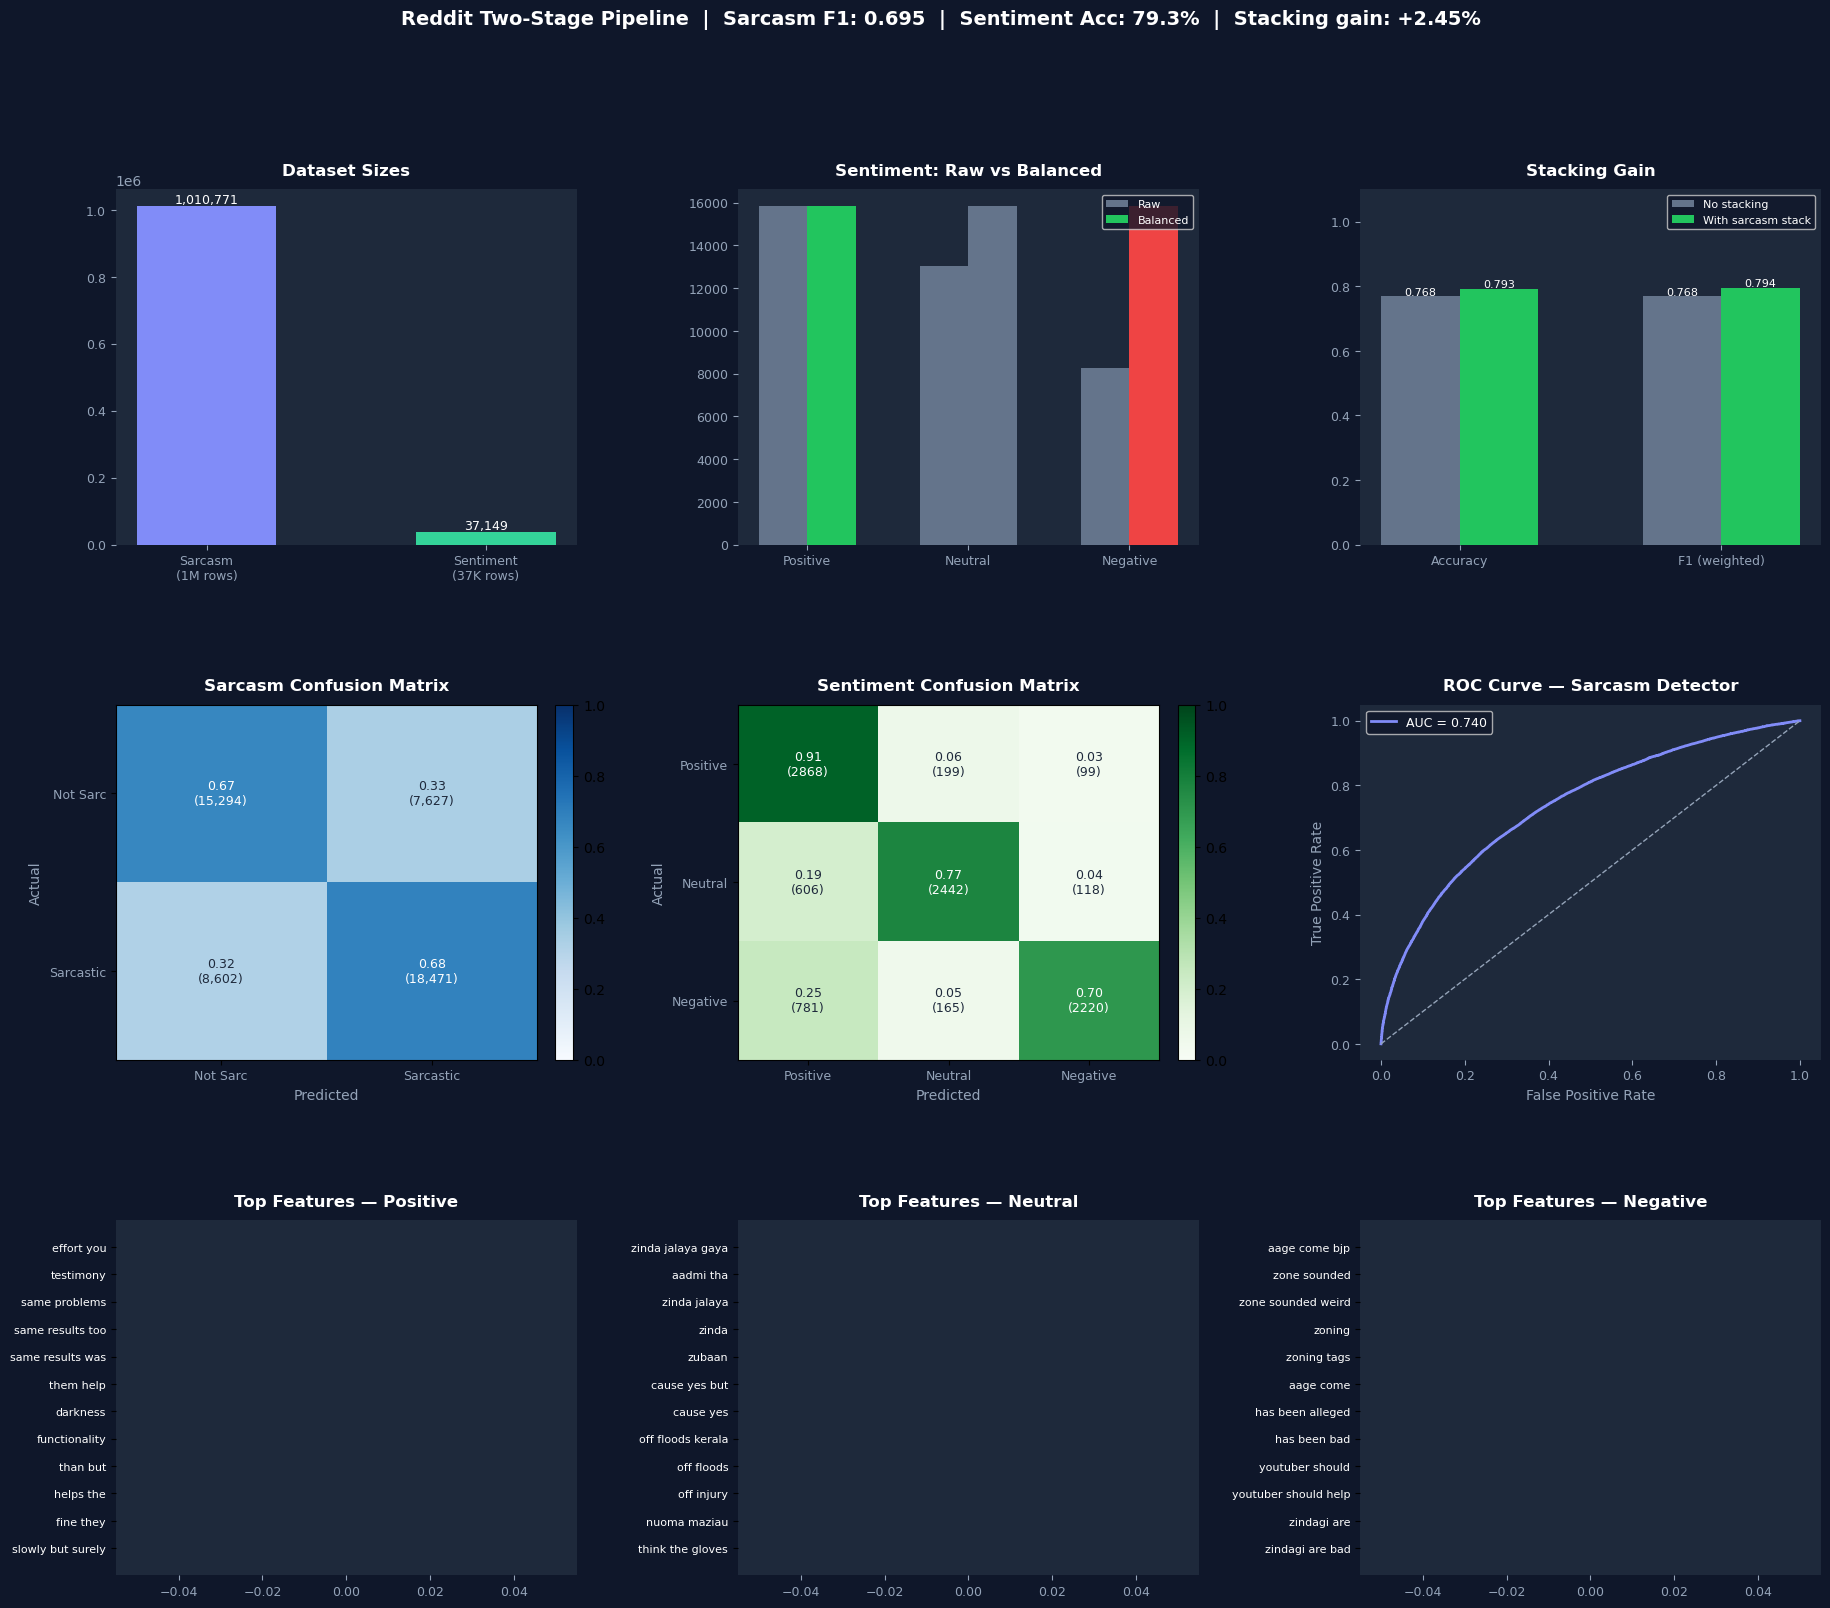


Total runtime : 2123s
Models saved  : nb_sarcasm_model.pkl  |  nb_sentiment_model.pkl
Plot saved    : reddit_pipeline_results.png


In [22]:
#Visualization Map
print("\nGenerating visualisations...")
 
BG    = '#0f172a'
PANEL = '#1e293b'
WHITE = 'white'
MUTED = '#94a3b8'
SC    = {'Positive':'#22c55e','Negative':'#ef4444','Neutral':'#64748b'}
 
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
titk = dict(color=WHITE, fontsize=12, fontweight='bold', pad=10)
tk   = dict(colors=MUTED, labelsize=9)
lk   = dict(color=MUTED, fontsize=10)
 
# ── 1. Dataset sizes ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.set_facecolor(PANEL)
names = ['Sarcasm\n(1M rows)', 'Sentiment\n(37K rows)']
sizes = [1010771, 37149]
bars  = ax.bar(names, sizes, color=['#818cf8','#34d399'], edgecolor='none', width=0.5)
for bar, v in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10000,
            f'{v:,}', ha='center', color=WHITE, fontsize=9)
ax.set_title('Dataset Sizes', **titk)
ax.tick_params(**tk); ax.spines[:].set_visible(False)
 
# ── 2. Sentiment label balance ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.set_facecolor(PANEL)
order  = ['Positive','Neutral','Negative']
raw_c  = [15830, 13042, 8277]
bal_c  = [target, target, target]
x = np.arange(3); w = 0.3
ax.bar(x-w/2, raw_c, w, label='Raw',      color='#64748b', edgecolor='none')
ax.bar(x+w/2, bal_c, w, label='Balanced', color=[SC[c] for c in order], edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(order, color=MUTED, fontsize=9)
ax.set_title('Sentiment: Raw vs Balanced', **titk)
ax.legend(fontsize=8, facecolor=BG, labelcolor=WHITE)
ax.tick_params(**tk); ax.spines[:].set_visible(False)
 
# ── 3. Stacking comparison ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.set_facecolor(PANEL)
x = np.arange(2); w = 0.3
b1 = ax.bar(x-w/2, [base_acc, base_f1], w,
            label='No stacking', color='#64748b', edgecolor='none')
b2 = ax.bar(x+w/2, [sent_acc, sent_f1], w,
            label='With sarcasm stack', color='#22c55e', edgecolor='none')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', color=WHITE, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(['Accuracy','F1 (weighted)'], color=MUTED, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Stacking Gain', **titk)
ax.legend(fontsize=8, facecolor=BG, labelcolor=WHITE)
ax.tick_params(**tk); ax.spines[:].set_visible(False)
 
# ── 4. Sarcasm confusion matrix ───────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.set_facecolor(PANEL)
cm   = confusion_matrix(y_sarc_test, sarc_preds)
cm_n = cm / cm.sum(axis=1, keepdims=True)
im   = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Not Sarc','Sarcastic'], color=MUTED, fontsize=9)
ax.set_yticklabels(['Not Sarc','Sarcastic'], color=MUTED, fontsize=9)
ax.set_xlabel('Predicted', **lk); ax.set_ylabel('Actual', **lk)
ax.set_title('Sarcasm Confusion Matrix', **titk)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_n[i,j]:.2f}\n({cm[i,j]:,})',
                ha='center', va='center', fontsize=9,
                color=WHITE if cm_n[i,j] > 0.5 else PANEL)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
 
# ── 5. Sentiment confusion matrix ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.set_facecolor(PANEL)
cm2  = confusion_matrix(y_sent_test, sent_preds, labels=order)
cm2n = cm2 / cm2.sum(axis=1, keepdims=True)
im2  = ax.imshow(cm2n, cmap='Greens', vmin=0, vmax=1, aspect='auto')
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(order, color=MUTED, fontsize=9)
ax.set_yticklabels(order, color=MUTED, fontsize=9)
ax.set_xlabel('Predicted', **lk); ax.set_ylabel('Actual', **lk)
ax.set_title('Sentiment Confusion Matrix', **titk)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm2n[i,j]:.2f}\n({cm2[i,j]})',
                ha='center', va='center', fontsize=9,
                color=WHITE if cm2n[i,j] > 0.5 else PANEL)
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
 
# ── 6. ROC curve — sarcasm ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.set_facecolor(PANEL)
fpr, tpr, _ = roc_curve(y_sarc_test, sarc_proba)
roc_auc     = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#818cf8', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0,1],[0,1], color=MUTED, lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate', **lk)
ax.set_ylabel('True Positive Rate', **lk)
ax.set_title('ROC Curve — Sarcasm Detector', **titk)
ax.legend(fontsize=9, facecolor=BG, labelcolor=WHITE)
ax.tick_params(**tk); ax.spines[:].set_visible(False)
 
# ── 7-9. Top features per sentiment class ─────────────────────────────────────
feat_names = sent_tfidf.get_feature_names_out()
log_prob   = sent_clf.feature_log_prob_[:, :-1]   # drop last col (sarcasm score)
classes    = list(sent_clf.classes_)
 
for col, cls in enumerate(order):
    ax = fig.add_subplot(gs[2, col])
    ax.set_facecolor(PANEL)
    idx     = classes.index(cls)
    top_idx = np.argsort(log_prob[idx])[-12:][::-1]
    scores  = log_prob[idx][top_idx]
    norm    = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    ax.barh(range(12), norm[::-1], color=SC[cls], edgecolor='none')
    ax.set_yticks(range(12))
    ax.set_yticklabels(feat_names[top_idx][::-1], fontsize=8, color=WHITE)
    ax.set_title(f'Top Features — {cls}', **titk)
    ax.tick_params(axis='x', **tk); ax.spines[:].set_visible(False)
 
fig.suptitle(
    f'Reddit Two-Stage Pipeline  |  Sarcasm F1: {sarc_f1:.3f}  '
    f'|  Sentiment Acc: {sent_acc*100:.1f}%  '
    f'|  Stacking gain: +{(sent_acc-base_acc)*100:.2f}%',
    color=WHITE, fontsize=14, fontweight='bold', y=0.98
)
 
plt.savefig('reddit_pipeline_results.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()
 
joblib.dump({'hv': hv, 'clf': sarc_clf},
            'nb_sarcasm_model.pkl')
joblib.dump({'tfidf': sent_tfidf, 'clf': sent_clf},
            'nb_sentiment_model.pkl')
 
print(f"\nTotal runtime : {time.time()-t0:.0f}s")
print("Models saved  : nb_sarcasm_model.pkl  |  nb_sentiment_model.pkl")
print("Plot saved    : reddit_pipeline_results.png")